<a href="https://colab.research.google.com/github/RegmiYogesh/Object_Centric_Patch-_sampling/blob/main/Singleclass_Deeplabv3%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
import torch.nn.functional as F
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.models import ResNet50_Weights
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd

In [10]:
from osgeo import gdal, osr, ogr
import glob
from sklearn.model_selection import train_test_split

In [5]:
train_image_dir = sorted(glob.glob(r"D:\Paper\cotton\images\*.tif"))
train_mask_dir = sorted(glob.glob(r"D:\Paper\cotton\labels\*.tif"))

In [6]:
# DOUBLE CHECK: Do the counts match?
print(f"Total Images: {len(train_image_dir)}")
print(f"Total Masks: {len(train_mask_dir)}")

Total Images: 1701
Total Masks: 1701


In [7]:
X = []
Y = []

for image_path, mask_path in zip(train_image_dir, train_mask_dir):
    # Load image using GDAL
    img_ds = gdal.Open(image_path)
    img = img_ds.ReadAsArray()
    img = img[:4, :, :]
    img = img.transpose(1, 2, 0)  # Transpose to (height, width, channels)
    X.append(img)

    # Load mask using GDAL
    mask_ds = gdal.Open(mask_path)
    mask = mask_ds.ReadAsArray()
    Y.append(mask)

# Convert lists to NumPy arrays
X = np.array(X)
Y = np.array(Y)

C:\ProgramData\miniconda3\envs\geoai\Lib\site-packages\osgeo\gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [11]:
# 1. Allocate 70% for training
train_xx, temp_xx, train_yy, temp_yy = train_test_split(
    X, Y, train_size=0.70, random_state=42
)

# 2. Split the remaining 30% into Validation (20%) and Test (10%)
# 20% of total = 2/3 of remaining 30%, so test_size=0.33
valid_xx, test_xx, valid_yy, test_yy = train_test_split(
    temp_xx, temp_yy, test_size=0.33, random_state=42
)

print(f"Training:   {train_xx.shape[0]} images (70%)")
print(f"Validation: {valid_xx.shape[0]} images (20%)")
print(f"Testing:    {test_xx.shape[0]} images (10%)")

Training:   1190 images (70%)
Validation: 342 images (20%)
Testing:    169 images (10%)


In [12]:
train_yy=np.array(train_yy).astype(int)
test_yy=np.array(test_yy).astype(int)
valid_yy=np.array(valid_yy).astype(int)

In [13]:
num_train = len(train_xx)
print (num_train)

#random image number
img_num = random.randint(0, num_train-1)
img_num

1190


22

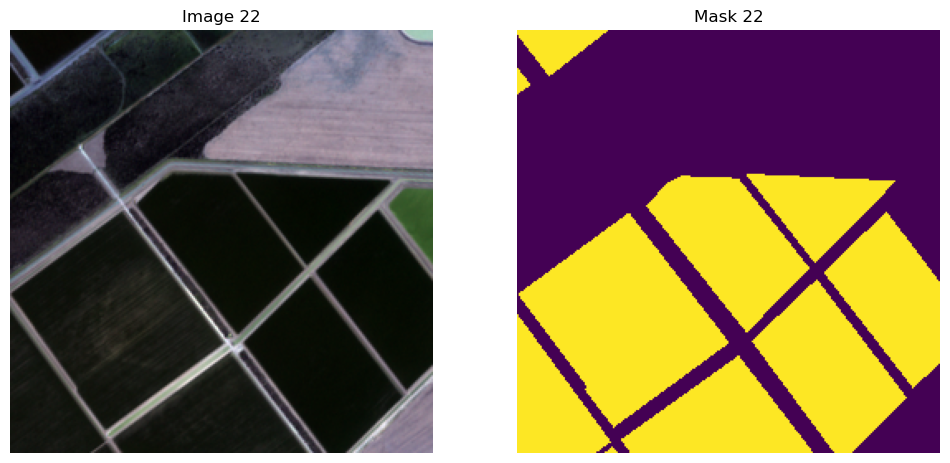

In [14]:
plt.figure(figsize=(12, 6))

image_to_plot = train_xx[img_num]
mask_to_plot = train_yy[img_num]

# For image visualization, select the first 3 channels and normalize for better contrast.
display_image = image_to_plot[:, :, :3]

# Ensure display_image is float for normalization
display_image = display_image.astype(np.float32)
for i in range(display_image.shape[-1]):
    min_val = display_image[:, :, i].min()
    max_val = display_image[:, :, i].max()
    if (max_val - min_val) > 0: # Avoid division by zero
        display_image[:, :, i] = (display_image[:, :, i] - min_val) / (max_val - min_val)

plt.subplot(1, 2, 1)
plt.title(f"Image {img_num}")
plt.imshow(display_image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Mask {img_num}")
plt.imshow(mask_to_plot) # Masks are typically grayscale
plt.axis('off')

plt.show()

In [15]:
import numpy as np

def scale_channels(data):
    # Create an empty array to hold the scaled data
    scaled_data = np.zeros_like(data, dtype=np.float32)

    # Scale each of the 4 channels independently
    for i in range(4):
        ch_min = np.min(data[..., i])
        ch_max = np.max(data[..., i])

        # Avoid division by zero if a channel is empty
        if ch_max - ch_min != 0:
            scaled_data[..., i] = (data[..., i] - ch_min) / (ch_max - ch_min)
        else:
            scaled_data[..., i] = 0.0

    return scaled_data

# Apply the scaling
train_xx = scale_channels(train_xx)
valid_xx = scale_channels(valid_xx)
test_xx = scale_channels(test_xx)

In [16]:
print(f"Min value of train_xx: {np.min(train_xx)}")
print(f"Max value of train_xx: {np.max(train_xx)}")
print(f"Min value of test_xx: {np.min(test_xx)}")
print(f"Max value of test_xx: {np.max(test_xx)}")
print(f"Min value of valid_xx: {np.min(valid_xx)}")
print(f"Max value of valid_xx: {np.max(valid_xx)}")

Min value of train_xx: 0.0
Max value of train_xx: 1.0
Min value of test_xx: 0.0
Max value of test_xx: 1.0
Min value of valid_xx: 0.0
Max value of valid_xx: 1.0


Validation Image 0 has 20519 cotton pixels.
Validation Image 1 has 18881 cotton pixels.
Validation Image 2 has 10692 cotton pixels.
Validation Image 3 has 59768 cotton pixels.
Validation Image 4 has 5121 cotton pixels.
Validation Image 5 has 14597 cotton pixels.
Validation Image 6 has 18765 cotton pixels.
Validation Image 7 has 14687 cotton pixels.
Validation Image 8 has 21515 cotton pixels.
Validation Image 9 has 16664 cotton pixels.


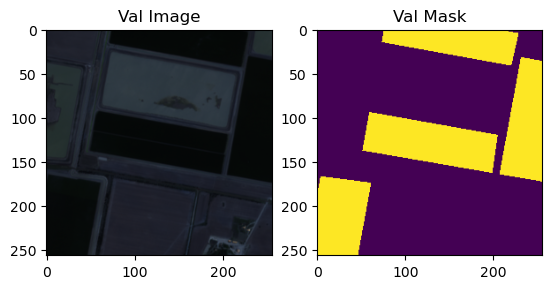

In [17]:
import matplotlib.pyplot as plt

# Check if validation masks actually contain cotton (1s)
for i in range(10):
    has_cotton = np.sum(valid_yy[i])
    print(f"Validation Image {i} has {has_cotton} cotton pixels.")

# Visualize one pair to be safe
plt.subplot(1,2,1)
plt.imshow(valid_xx[0][:,:,:3]) # Show RGB
plt.title("Val Image")
plt.subplot(1,2,2)
plt.imshow(valid_yy[0]) # Show Mask
plt.title("Val Mask")
plt.show()

In [24]:
import segmentation_models_pytorch as smp

# Initialize DeepLabV3+ model for 1-class binary segmentation
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=4,
    classes=1, # Changed to 1 for 1-class binary segmentation
    activation=None # Keep None, BCEWithLogitsLoss will handle sigmoid
)

In [32]:
import torch
from torch.utils.data import DataLoader, Dataset


class SegmentationDataset(Dataset):

  def __init__(self, images, masks):
    # Transpose images from (H, W, C) to PyTorch shape (C, H, W)
    self.images = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
    # Masks should be long tensors of shape (H, W) with class indices (0, 1, 2)
    self.masks = torch.tensor(masks, dtype=torch.long)

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    return self.images[idx], self.masks[idx]


# Create PyTorch Datasets
train_dataset = SegmentationDataset(train_xx, train_yy)
valid_dataset = SegmentationDataset(valid_xx, valid_yy)

# Create DataLoaders
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

In [30]:
# Setup GPU execution
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Multiclass segmentation loss
criterion = nn.CrossEntropyLoss()

# Adam/AdamW optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


In [31]:
# 1. Combined BCEWithLogits + Dice Loss for binary segmentation
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode="binary", from_logits=True)

def criterion(outputs, targets):
  # BCEWithLogitsLoss expects outputs (logits) as (N, H, W) and targets as (N, H, W) floats
  # DiceLoss(mode='binary', from_logits=True) expects outputs (logits) as (N, 1, H, W) and targets as (N, H, W) floats
  # So, we need to squeeze outputs for BCE and ensure targets are float.
  return bce_loss(outputs.squeeze(1), targets.float()) + dice_loss(outputs, targets.float())

# 2. Re-initialize Optimizer & Cosine Annealing Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=100, eta_min=1e-6
)

In [36]:
import time

def compute_metrics(preds, targets, num_classes=2):
  """Computes Mean IoU and Macro F1 Score for multi-class prediction."""
  ious = []
  f1_scores = []

  for c in range(num_classes):
    pred_c = preds == c
    target_c = targets == c

    intersection = (pred_c & target_c).sum().float().item()
    union = (pred_c | target_c).sum().float().item()
    total_pixels = pred_c.sum().float().item() + target_c.sum().float().item()

    # IoU
    iou = (intersection + 1e-7) / (union + 1e-7) if union > 0 else 1.0
    ious.append(iou)

    # F1 Score / Dice
    f1 = (
        (2 * intersection + 1e-7) / (total_pixels + 1e-7)
        if total_pixels > 0
        else 1.0
    )
    f1_scores.append(f1)

  return np.mean(ious), np.mean(f1_scores)


# History tracker
history = {
    "train_loss": [],
    "val_loss": [],
    "train_miou": [], # Added for training mIoU
    "train_mf1": [],  # Added for training mF1
    "val_miou": [],
    "val_mf1": [],
    "lr": [],
}

num_epochs = 25
best_val_loss = float("inf")

# Early stopping parameters
patience = 12
patience_counter = 0

for epoch in range(num_epochs):
  start_time = time.time()

  # Track Learning Rate
  current_lr = optimizer.param_groups[0]["lr"]
  history["lr"].append(current_lr)

  # --- TRAINING PHASE ---
  model.train()
  train_loss = 0.0
  train_all_preds, train_all_masks = [], [] # Accumulators for training metrics

  for images, masks in train_loader:
    images, masks = images.to(device), masks.to(device)

    optimizer.zero_grad()
    logits = model(images) # Model outputs logits for 1 channel
    loss = criterion(logits, masks)

    loss.backward()
    optimizer.step()

    train_loss += loss.item() * images.size(0)

    # Store batch predictions for training evaluation (apply sigmoid and threshold for binary output)
    preds = (torch.sigmoid(logits.squeeze(1)) > 0.5).long()
    train_all_preds.append(preds.cpu())
    train_all_masks.append(masks.cpu())

  train_loss = train_loss / len(train_loader.dataset)
  history["train_loss"].append(train_loss)

  # Compute training metrics
  train_all_preds = torch.cat(train_all_preds, dim=0)
  train_all_masks = torch.cat(train_all_masks, dim=0)
  train_miou, train_mf1 = compute_metrics(train_all_preds, train_all_masks, num_classes=2)
  history["train_miou"].append(train_miou)
  history["train_mf1"].append(train_mf1)

  # --- VALIDATION PHASE ---
  model.eval()
  valid_loss = 0.0
  all_preds, all_masks = [], []

  with torch.no_grad():
    for images, masks in valid_loader:
      images, masks = images.to(device), masks.to(device)

      logits = model(images) # Model outputs logits for 1 channel
      loss = criterion(logits, masks)

      valid_loss += loss.item() * images.size(0)

      # Store batch predictions for evaluation (apply sigmoid and threshold for binary output)
      preds = (torch.sigmoid(logits.squeeze(1)) > 0.5).long() # Squeeze 1 channel and threshold
      all_preds.append(preds.cpu())
      all_masks.append(masks.cpu())

  valid_loss = valid_loss / len(valid_loader.dataset)
  history["val_loss"].append(valid_loss)

  # Compute epoch metrics
  all_preds = torch.cat(all_preds, dim=0)
  all_masks = torch.cat(all_masks, dim=0)
  val_miou, val_mf1 = compute_metrics(all_preds, all_masks, num_classes=2)

  history["val_miou"].append(val_miou)
  history["val_mf1"].append(val_mf1)

  # Step the scheduler per epoch
  scheduler.step()

  elapsed = time.time() - start_time
  print(
      f"Epoch {epoch+1:02d}/{num_epochs:02d} | "
      f"Train Loss: {train_loss:.4f} | Train mIoU: {train_miou:.4f} | Train F1: {train_mf1:.4f} | " # Updated print statement
      f"Val Loss: {valid_loss:.4f} | Val mIoU: {val_miou:.4f} | Val F1: {val_mf1:.4f} | "
      f"LR: {current_lr:.1e} | Time: {elapsed:.1f}s"
  )

  # --- MODEL CHECKPOINTING & EARLY STOPPING ---
  if valid_loss < best_val_loss:
    best_val_loss = valid_loss
    patience_counter = 0  # Reset counter
    torch.save(model.state_dict(), "best_deeplabv3plus_singleclass.pth")
    print(f"  --> Saved new best checkpoint (Val Loss: {valid_loss:.4f})")
  else:
    patience_counter += 1
    if patience_counter >= patience:
      print(f"\n[Early Stopping Triggered] No improvement for {patience} epochs.")
      break

Epoch 01/25 | Train Loss: 0.0658 | Train mIoU: 0.9731 | Train F1: 0.9863 | Val Loss: 0.2864 | Val mIoU: 0.9209 | Val F1: 0.9586 | LR: 1.0e-04 | Time: 32.9s
  --> Saved new best checkpoint (Val Loss: 0.2864)
Epoch 02/25 | Train Loss: 0.0550 | Train mIoU: 0.9760 | Train F1: 0.9878 | Val Loss: 0.3714 | Val mIoU: 0.9049 | Val F1: 0.9497 | LR: 1.0e-04 | Time: 32.5s
Epoch 03/25 | Train Loss: 0.0455 | Train mIoU: 0.9799 | Train F1: 0.9898 | Val Loss: 0.2924 | Val mIoU: 0.9214 | Val F1: 0.9588 | LR: 1.0e-04 | Time: 32.6s
Epoch 04/25 | Train Loss: 0.0386 | Train mIoU: 0.9827 | Train F1: 0.9913 | Val Loss: 0.3472 | Val mIoU: 0.9141 | Val F1: 0.9548 | LR: 1.0e-04 | Time: 32.6s
Epoch 05/25 | Train Loss: 0.0370 | Train mIoU: 0.9841 | Train F1: 0.9920 | Val Loss: 0.3777 | Val mIoU: 0.9085 | Val F1: 0.9517 | LR: 9.9e-05 | Time: 32.6s
Epoch 06/25 | Train Loss: 0.0336 | Train mIoU: 0.9847 | Train F1: 0.9923 | Val Loss: 0.4743 | Val mIoU: 0.9025 | Val F1: 0.9484 | LR: 9.9e-05 | Time: 32.6s
Epoch 07/25 |

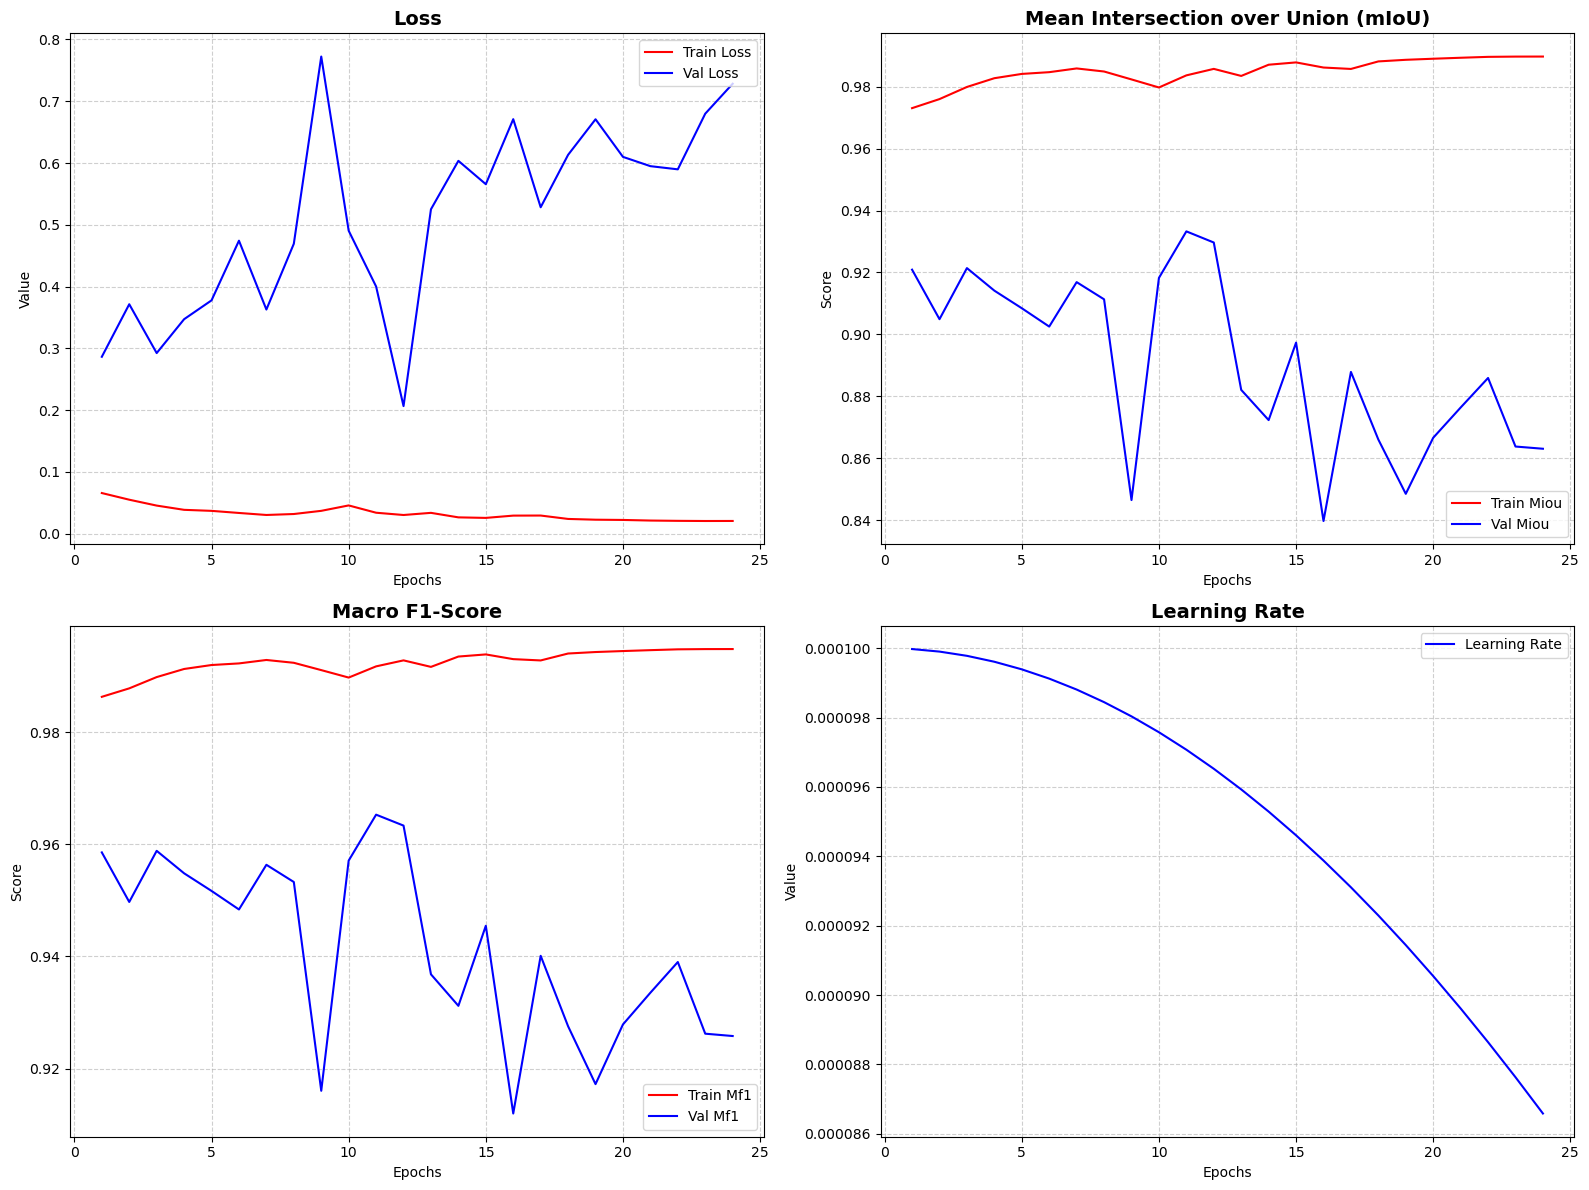

All performance graphs exported to: D:\Paper\visualization\singleclass


In [37]:
import os
import matplotlib.pyplot as plt


def plot_all_metrics(
    history, output_dir=r"D:\Paper\visualization\singleclass"
):
  # Define the metrics to plot: (metric_key, title, y_label)
  metrics_to_plot = [
      ("loss", "Loss", "Value"),
      ("miou", "Mean Intersection over Union (mIoU)", "Score"),
      ("mf1", "Macro F1-Score", "Score"),
      ("lr", "Learning Rate", "Value"),
  ]

  # Epochs range based on history length
  epochs = range(1, len(history["val_loss"]) + 1)

  # --- 1. DISPLAY COMBINED 2x2 SUBPLOT GRID ---
  fig, axs = plt.subplots(2, 2, figsize=(16, 12))
  axs = axs.ravel()  # Flatten grid for easy looping

  for i, (metric_key, title, ylabel) in enumerate(metrics_to_plot):
    train_key = f"train_{metric_key}"
    val_key = f"val_{metric_key}"

    # Plot Train Metric if present
    if train_key in history:
      axs[i].plot(
          epochs,
          history[train_key],
          "r",
          label=f'Train {metric_key.replace("_", " ").title()}',
      )

    # Plot Validation Metric if present
    if val_key in history:
      axs[i].plot(
          epochs,
          history[val_key],
          "b",
          label=f'Val {metric_key.replace("_", " ").title()}',
      )

    # Plot standalone Learning Rate if metric_key is 'lr'
    if metric_key == "lr" and "lr" in history:
      axs[i].plot(epochs, history["lr"], "b", label="Learning Rate")

    axs[i].set_title(title, fontsize=14, fontweight="bold")
    axs[i].set_xlabel("Epochs")
    axs[i].set_ylabel(ylabel)

    # Legend location matching reference rule
    if metric_key in ["loss", "lr"]:
      axs[i].legend(loc="upper right")
    else:
      axs[i].legend(loc="lower right")

    axs[i].grid(True, linestyle="--", alpha=0.6)

  plt.tight_layout()
  plt.show()

  # --- 2. SAVE INDIVIDUAL GRAPH IMAGES ---
  os.makedirs(output_dir, exist_ok=True)

  for metric_key, title, ylabel in metrics_to_plot:
    plt.figure(figsize=(10, 6))

    train_key = f"train_{metric_key}"
    val_key = f"val_{metric_key}"

    # Plot Train Metric
    if train_key in history:
      plt.plot(
          epochs,
          history[train_key],
          "b",
          label=f'Train {metric_key.replace("_", " ").title()}',
      )

    # Plot Validation Metric
    if val_key in history:
      plt.plot(
          epochs,
          history[val_key],
          "r",
          label=f'Val {metric_key.replace("_", " ").title()}',
      )

    # Plot Learning Rate
    if metric_key == "lr" and "lr" in history:
      plt.plot(epochs, history["lr"], "b", label="Learning Rate")

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)

    # Legend location setting
    if metric_key in ["loss", "lr"]:
      plt.legend(loc="upper right")
    else:
      plt.legend(loc="lower right")

    plt.grid(True, linestyle="--", alpha=0.6)

    # Save figure with high quality
    save_file = os.path.join(output_dir, f"{metric_key}_plot.png")
    plt.savefig(save_file, dpi=600, bbox_inches="tight")
    plt.close()  # Close to free up memory

  print(f"All performance graphs exported to: {output_dir}")


# Run the function
plot_all_metrics(history)

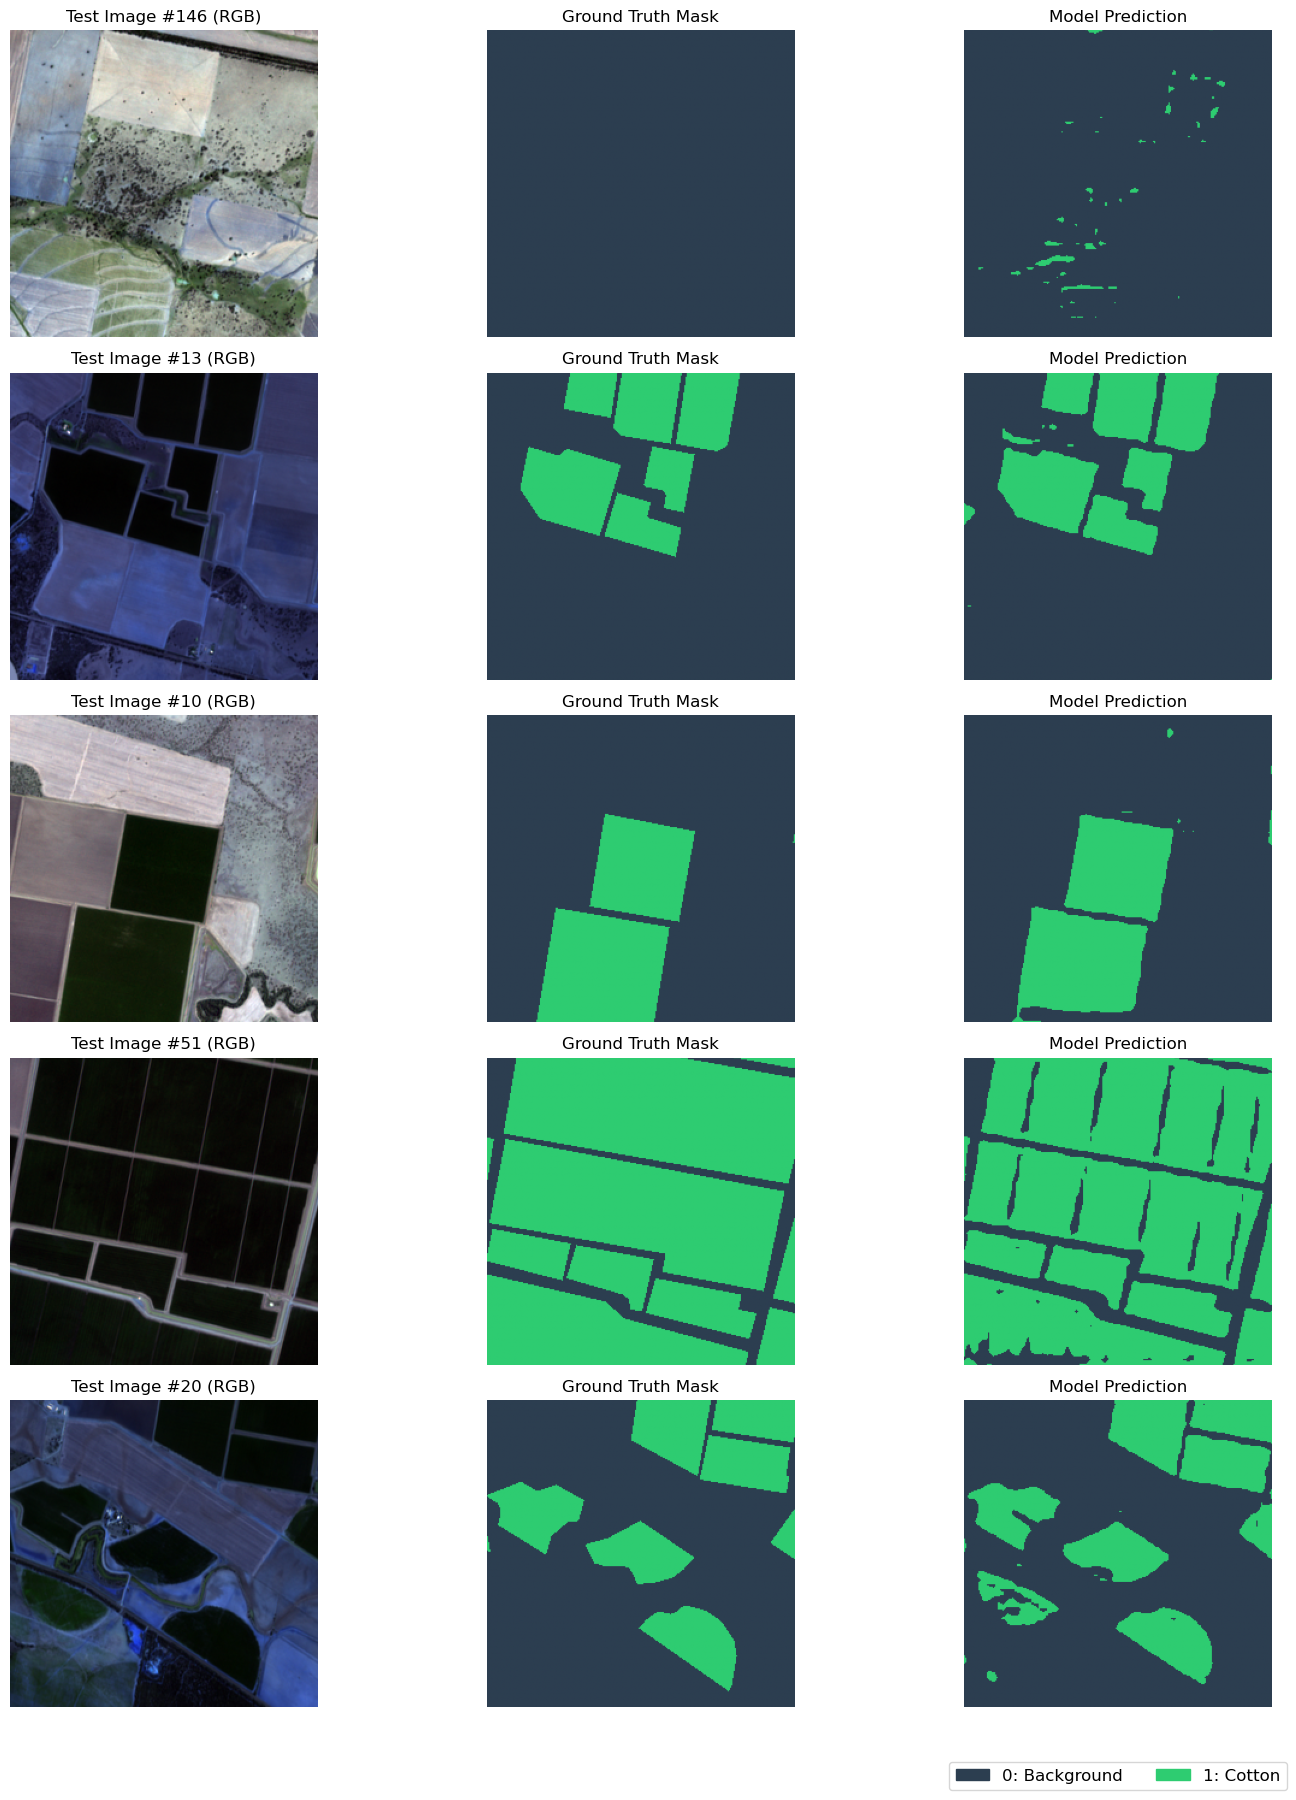

In [40]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import torch

# 1. Load the best saved model weights
model.load_state_dict(torch.load("best_deeplabv3plus_singleclass.pth"))
model.eval()

# 2. Pick 5 random indices from the test set
num_test = len(test_xx)
random_indices = np.random.choice(num_test, size=5, replace=False)

# 3. Define a custom colormap for class visualization (2 classes: Background, Cotton)
cmap = ListedColormap(["#2c3e50", "#2ecc71"])

# Setup matplotlib figure
fig, axes = plt.subplots(5, 3, figsize=(15, 18))

with torch.no_grad():
  for idx, test_idx in enumerate(random_indices):
    # Prepare image tensor: (H, W, C) -> (1, C, H, W)
    raw_img = test_xx[test_idx]
    gt_mask = test_yy[test_idx]

    img_tensor = (
        torch.tensor(raw_img, dtype=torch.float32)
        .permute(2, 0, 1)
        .unsqueeze(0)
        .to(device)
    )

    # Make prediction
    logits = model(img_tensor)  # Model outputs logits for 1 channel
    pred_mask = (torch.sigmoid(logits.squeeze(1)) > 0.5).squeeze(0).cpu().numpy() # Squeeze 1 channel and threshold

    # --- Plot 1: RGB Image ---
    # Take first 3 channels (RGB) and normalize per channel for clear display
    rgb_img = raw_img[:, :, :3].copy()
    for c in range(3):
      min_val, max_val = rgb_img[:, :, c].min(), rgb_img[:, :, c].max()
      if max_val > min_val:
        rgb_img[:, :, c] = (rgb_img[:, :, c] - min_val) / (max_val - min_val)

    axes[idx, 0].imshow(rgb_img)
    axes[idx, 0].set_title(f"Test Image #{test_idx} (RGB)")
    axes[idx, 0].axis("off")

    # --- Plot 2: Ground Truth Mask ---
    axes[idx, 1].imshow(gt_mask, cmap=cmap, vmin=0, vmax=1) # vmax changed to 1 for binary
    axes[idx, 1].set_title("Ground Truth Mask")
    axes[idx, 1].axis("off")

    # --- Plot 3: Predicted Mask ---
    axes[idx, 2].imshow(pred_mask, cmap=cmap, vmin=0, vmax=1) # vmax changed to 1 for binary
    axes[idx, 2].set_title("Model Prediction")
    axes[idx, 2].axis("off")

# Add class legend at the bottom
patches = [
    mpatches.Patch(color="#2c3e50", label="0: Background"),
    mpatches.Patch(color="#2ecc71", label="1: Cotton")
]
plt.legend(
    handles=patches,
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=2,
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [41]:
import os
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
import numpy as np
import torch

# Define output directory to save individual patches
output_dir = r"D:\Paper\visualization\test_patches"
os.makedirs(output_dir, exist_ok=True)

# 1. Load the best saved model weights
model.load_state_dict(torch.load("best_deeplabv3plus_multiclass.pth"))
model.eval()

# 2. Pick 5 random indices from the test set
num_test = len(test_xx)
random_indices = np.random.choice(num_test, size=5, replace=False)

# 3. Custom colormap for class visualization (2 classes: Background, Cotton)
cmap = ListedColormap(["#2c3e50", "#2ecc71"])

# --- SAVE INDIVIDUAL PATCHES ---
with torch.no_grad():
  for idx, test_idx in enumerate(random_indices):
    raw_img = test_xx[test_idx]
    gt_mask = test_yy[test_idx]

    # Prepare image tensor
    img_tensor = (
        torch.tensor(raw_img, dtype=torch.float32)
        .permute(2, 0, 1)
        .unsqueeze(0)
        .to(device)
    )

    # Get model prediction
    logits = model(img_tensor) # Model outputs logits for 1 channel
    pred_mask = (torch.sigmoid(logits.squeeze(1)) > 0.5).squeeze(0).cpu().numpy() # Squeeze 1 channel and threshold

    # --- Prepare RGB Image ---
    rgb_img = raw_img[:, :, :3].copy()
    for c in range(3):
      min_val, max_val = rgb_img[:, :, c].min(), rgb_img[:, :, c].max()
      if max_val > min_val:
        rgb_img[:, :, c] = (rgb_img[:, :, c] - min_val) / (max_val - min_val)

    # 1. Save RGB Image Patch
    plt.figure(figsize=(6, 6))
    plt.imshow(rgb_img)
    plt.axis("off")
    plt.savefig(
        os.path.join(output_dir, f"sample_{test_idx}_rgb.png"),
        bbox_inches="tight",
        pad_inches=0,
        dpi=300,
    )
    plt.close()

    # 2. Save Ground Truth Mask Patch
    plt.figure(figsize=(6, 6))
    plt.imshow(gt_mask, cmap=cmap, vmin=0, vmax=1) # vmax changed to 1 for binary
    plt.axis("off")
    plt.savefig(
        os.path.join(output_dir, f"sample_{test_idx}_gt.png"),
        bbox_inches="tight",
        pad_inches=0,
        dpi=300,
    )
    plt.close()

    # 3. Save Predicted Mask Patch
    plt.figure(figsize=(6, 6))
    plt.imshow(pred_mask, cmap=cmap, vmin=0, vmax=1) # vmax changed to 1 for binary
    plt.axis("off")
    plt.savefig(
        os.path.join(output_dir, f"sample_{test_idx}_pred.png"),
        bbox_inches="tight",
        pad_inches=0,
        dpi=300,
    )
    plt.close()

print(f"All individual patches successfully saved to: {output_dir}")

All individual patches successfully saved to: D:\Paper\visualization\test_patches
